## Imports

In [18]:
import os
import glob
import datetime

import jax
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hssm
import arviz as az
import seaborn as sns

import sqlite3

jax.config.update('jax_platform_name', 'cpu')
hssm.set_floatX("float32")
numpyro.set_host_device_count(14)

Setting PyTensor floatX type to float32.
Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [19]:
df_raw = pd.read_stata('Data_Exp1234_clean.dta')

In [20]:
df_raw

,confidence,correct,true_shock,ab_nominal,rt,endowment,concentration,anxiety,totalmistakes,age,...,stake,stake_nominal,difficult,aligned,wishful,confusioncontrol,never_felt_deceived,bai,dpessimism,idtreatmentblock
0,0.60,1,1,20.00,4349.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,0.0,1.0,22.916664,NaN,5.0,1.190476,NaN,10.0
1,0.60,1,0,20.00,3796.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,1.0,0.0,22.916664,NaN,5.0,1.190476,NaN,10.0
2,0.65,0,0,20.00,2201.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,1.0,1.0,22.916664,NaN,5.0,1.190476,NaN,10.0
3,0.80,1,0,20.00,2945.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,0.0,0.0,22.916664,NaN,5.0,1.190476,NaN,10.0
4,0.70,0,0,20.00,3405.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,2.0,0.0,22.916664,NaN,5.0,1.190476,NaN,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97628,NaN,1,1,0.05,14534.5,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,0.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0
97629,NaN,1,0,0.05,15099.3,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,0.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0
97630,NaN,1,1,0.05,1715.6,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,2.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0
97631,NaN,0,1,0.05,2599.6,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,3.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0


In [95]:
df_raw[df_raw['experiment']==4].rt.dropna().sort_values()

71534        1.0
71535      154.7
79607      245.7
73836      254.0
79612      259.0
          ...   
94022    35534.5
94003    36889.4
73470    37662.8
88431    38092.8
86541    38303.2
Name: rt, Length: 34133, dtype: float64

<Axes: xlabel='rt', ylabel='Density'>

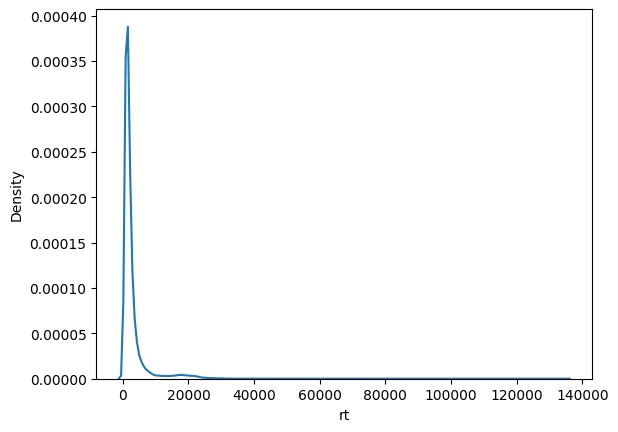

In [96]:
sns.kdeplot(df_raw.rt)

## Definitions

In [21]:
def subsitute_values_sequential(data,varname,new_values):
  unique_values = sorted(data[varname].unique())
  substitutions = {val: new_val for val, new_val in zip(unique_values,new_values)}
  return  data[varname].replace(substitutions)

In [22]:
def robust_z(x):
    x = np.asarray(x, float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 0.6745 * (x - med) / (mad if mad>0 else np.finfo(float).eps)

In [23]:
def fit_hssm_participant(df, participant_column):
    all_summaries = []
    all_inferences = {}   # <- store InferData here

    for nsub, isub in enumerate(df[participant_column].unique()):
        print(f"___Participant {isub}, {nsub+1}/{df[participant_column].nunique()}___")

        df_sub = df[df[participant_column] == isub].drop(columns=[participant_column])

        print("Median RT =", np.median(df_sub['rt']))
        print("N trials =", len(df_sub))

        model = hssm.HSSM(
            model="ddm",
            data=df_sub,
        )

        infer_data_sub = model.sample(
            cores=3,
            chains=3,
            draws=300,
            tune=1000,
            idata_kwargs=dict(log_likelihood=True),
            progressbar=True,
            target_accept=0.99,
        )

        all_inferences[isub] = infer_data_sub

        summary_df = (
            az.summary(infer_data_sub)
              .reset_index()
              .rename(columns={'index': 'param'})
        )
        summary_df['participant_id'] = isub
        all_summaries.append(summary_df)

    all_summaries_df = pd.concat(all_summaries, ignore_index=True)
    return all_summaries_df, all_inferences

In [24]:
def write_to_sql(df, db_name, table_name):
    conn = sqlite3.connect(db_name)
    df.to_sql(table_name, conn, if_exists="append", index=False)
    conn.close()

### Data Cleanup

In [25]:
columns_to_keep = [
    'id',              # Participant ID (for hierarchical fitting)
    'trial',           # Trial Number (for indexing/sequencing)
    'experiment',      # Filter column (must be 4)
    'rt',              # Response Time (The dependent variable distribution)
    'correct',         # Accuracy (The outcome predicted by DDM)
    'ab_nominal',      # Accuracy Bonus (Incentive condition)
    'stake_nominal',   # Loss Size (Incentive condition)
    'difficult',        # Task Difficulty (Signal quality condition)
    'endowment',      # Initial amount (Incentive con
]

In [26]:
data = df_raw.copy()
data = data[columns_to_keep]

data.rename(columns={
    'id':'participant'
}, inplace=True)

## Stim evidence: low vs high (0/1)
#data['endowment_2'] = subsitute_values_sequential(data,'stim_strength',[0.25,.5,0.75,1])

MIN_RT = 200 
MAX_RT = 35000 
MAD_THRESH_RT = 3

ACC_THRESH_LO = 0.525 
ACC_THRESH_HI = 0.975

MIN_TRIALS_PER_COND = 8
COND_VARS = ['endowment']

#count original number of trials before exclusion
n_trials_raw= len(data)

In [27]:
data = data[(~data['correct'].isna()) & (~data['rt'].isna())
             & (data['rt']> MIN_RT) & (data['rt'] < MAX_RT) & (~data['correct'].isna())]

In [28]:
data = data[data.groupby('participant')['rt'].transform(lambda x: abs(robust_z(x)))<MAD_THRESH_RT]

In [29]:
print('N trials excluded = %i / %i'%(n_trials_raw - len(data),n_trials_raw))

print('Mean RT = %i ms, median RT = %i ms, max RT = %i ms' % (data['rt'].mean(),data['rt'].median(),data['rt'].max()))

N trials excluded = 8259 / 97633
Mean RT = 2488 ms, median RT = 1525 ms, max RT = 34963 ms


In [30]:
data

,participant,trial,experiment,rt,correct,ab_nominal,stake_nominal,difficult,endowment
1,1.0,2.0,1.0,3796.0,1,20.00,NaN,1.0,NaN
2,1.0,3.0,1.0,2201.0,0,20.00,NaN,1.0,NaN
3,1.0,4.0,1.0,2945.0,1,20.00,NaN,0.0,NaN
4,1.0,5.0,1.0,3405.0,0,20.00,NaN,2.0,NaN
5,1.0,6.0,1.0,1844.0,0,20.00,NaN,2.0,NaN
...,...,...,...,...,...,...,...,...,...
97628,1114.0,71.0,4.0,14534.5,1,0.05,0.0,0.0,0.0
97629,1114.0,72.0,4.0,15099.3,1,0.05,0.0,0.0,0.0
97630,1114.0,73.0,4.0,1715.6,1,0.05,0.0,2.0,0.0
97631,1114.0,74.0,4.0,2599.6,0,0.05,0.0,3.0,0.0


In [31]:
data.to_clipboard()

## Participant Cleanup

In [32]:
data = data[data['experiment']==4]

In [33]:
participant_accuracy = data.groupby('participant')['correct'].mean()
valid_participants = participant_accuracy[(participant_accuracy > ACC_THRESH_LO) & (participant_accuracy < ACC_THRESH_HI)].index

print('N participants kept (accuracy) = %i / %i'%(len(valid_participants),len(data['participant'].unique())))
data = data[data['participant'].isin(valid_participants)]

#remove participants with extreme median RTs compared to sample
participant_rt = data.groupby('participant')['rt'].median()
valid_participants_rt = participant_rt[np.abs(robust_z(participant_rt))<3].index
print('N participants kept (RT) = %i / %i'%(len(valid_participants_rt),len(data['participant'].unique())))
data = data[data['participant'].isin(valid_participants_rt)]

# remove participants, who, after exclsion, have too few trials for one or more conditions
groupby_vars = ['participant']
groupby_vars.extend(COND_VARS)
sub_trials_per_cond = data.groupby(groupby_vars).size().reset_index(name='n_trials')

#get list of participants that have at least min_trials_per_cond trials per condition (combination of incentive and desirability values)
df_participants_with_min_trials = sub_trials_per_cond.groupby('participant').filter(lambda x: (x['n_trials'] >= MIN_TRIALS_PER_COND).all())
valid_participants = df_participants_with_min_trials['participant'].unique().tolist()
print('N participants kept after excluding participants with too few trials = %i / %i'%(len(valid_participants),len(data['participant'].unique())))
data = data[data['participant'].isin(valid_participants)]

N participants kept (accuracy) = 397 / 407
N participants kept (RT) = 343 / 397
N participants kept after excluding participants with too few trials = 343 / 343


In [34]:
data = data[data['experiment']==4]

In [35]:
len(data.participant.unique())

343

## HSSM DataFrame

In [52]:
data

,participant,trial,experiment,rt,correct,ab_nominal,stake_nominal,difficult,endowment
63495,708.0,1.0,4.0,1454.6,0,0.05,0.0,3.0,0.0
63496,708.0,2.0,4.0,2016.7,0,0.05,0.0,0.0,0.0
63497,708.0,3.0,4.0,959.7,1,0.05,0.0,0.0,0.0
63498,708.0,4.0,4.0,910.2,1,0.05,0.0,3.0,0.0
63499,708.0,5.0,4.0,1021.8,0,0.05,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...
97552,1113.0,79.0,4.0,1329.4,1,10.00,1.0,0.0,5.0
97553,1113.0,80.0,4.0,1506.9,1,10.00,1.0,1.0,5.0
97554,1113.0,81.0,4.0,1345.2,1,10.00,1.0,0.0,5.0
97555,1113.0,82.0,4.0,2321.0,0,10.00,1.0,3.0,5.0


In [37]:
df_hssm = pd.DataFrame({
    'response': data['correct'].astype('int32'),
    'rt': (data['rt'] / 1000).astype('float32'),
    'participant_id': data['participant'].astype('int32')
})

df_hssm = df_hssm.astype({col: 'float32' for col in df_hssm.select_dtypes(include='float64').columns})

In [38]:
df_hssm

,response,rt,participant_id
63495,0,1.4546,708
63496,0,2.0167,708
63497,1,0.9597,708
63498,1,0.9102,708
63499,0,1.0218,708
...,...,...,...
97552,1,1.3294,1113
97553,1,1.5069,1113
97554,1,1.3452,1113
97555,0,2.3210,1113


In [86]:
df_hssm.to_csv('hssm_exp4_data.csv', index=False)

# Test dataset

In [40]:
random_ids = np.random.choice(
    df_hssm.participant_id.unique(),
    size=round(len(df_hssm.participant_id.unique())),
    replace = False
)

In [41]:
df_test = df_hssm[df_hssm['participant_id'].isin(random_ids)]

In [42]:
df_hssm.participant_id.nunique(), df_test.participant_id.nunique()

(343, 343)

In [43]:
df_test

,response,rt,participant_id
63495,0,1.4546,708
63496,0,2.0167,708
63497,1,0.9597,708
63498,1,0.9102,708
63499,0,1.0218,708
...,...,...,...
97552,1,1.3294,1113
97553,1,1.5069,1113
97554,1,1.3452,1113
97555,0,2.3210,1113


# Partial dataset for fitting

In [44]:
part_df = df_test.copy()

In [45]:
fitted_participantd_ids = pd.read_sql_query("SELECT DISTINCT participant_id FROM summaries", sqlite3.connect('hssm_fits.db'))

In [46]:
len(fitted_participantd_ids)

343

In [47]:
df_test

,response,rt,participant_id
63495,0,1.4546,708
63496,0,2.0167,708
63497,1,0.9597,708
63498,1,0.9102,708
63499,0,1.0218,708
...,...,...,...
97552,1,1.3294,1113
97553,1,1.5069,1113
97554,1,1.3452,1113
97555,0,2.3210,1113


In [48]:
part_df = df_test[~df_test['participant_id'].isin(fitted_participantd_ids.participant_id.values)]

In [49]:
part_df.participant_id.nunique()

0

## Fit model

In [50]:
df_fit_output, az_data = fit_hssm_participant(part_df, 'participant_id')

ValueError: No objects to concatenate

In [ ]:
df_fit_output

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
0,v,0.618,0.146,0.337,0.891,0.009,0.006,298.0,310.0,1.00,710
1,z,0.484,0.054,0.389,0.586,0.004,0.003,224.0,260.0,1.00,710
2,t,1.183,0.068,1.064,1.290,0.006,0.004,131.0,267.0,1.01,710
3,a,1.226,0.078,1.082,1.353,0.006,0.004,184.0,125.0,1.02,710
4,v,0.033,0.115,-0.193,0.240,0.005,0.004,464.0,535.0,1.00,723
...,...,...,...,...,...,...,...,...,...,...,...
131,a,1.159,0.066,1.051,1.283,0.004,0.003,373.0,465.0,1.01,1085
132,v,0.483,0.144,0.229,0.765,0.006,0.004,619.0,537.0,1.00,1111
133,z,0.425,0.041,0.351,0.502,0.002,0.001,589.0,587.0,1.00,1111
134,t,0.464,0.047,0.373,0.541,0.004,0.003,177.0,244.0,1.02,1111


# store data

In [ ]:
write_to_sql(df_fit_output, 'hssm_fits.db', 'summaries')

# az plot

In [ ]:
#az.plot_posterior(az_data[1080])

# Drift rate plots

In [ ]:
df_v = df_fit_output[df_fit_output['param']=='v']

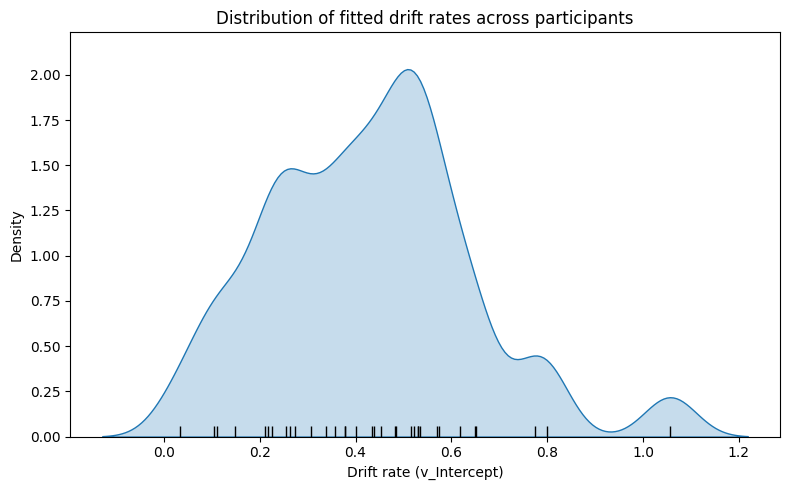

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_v['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_v['mean'], color='k')
plt.xlabel("Drift rate (v_Intercept)")
plt.ylabel("Density")
plt.title("Distribution of fitted drift rates across participants")
plt.tight_layout()
plt.show()

# Read SQL

In [53]:
query = "SELECT * FROM summaries"
conn = sqlite3.connect('hssm_fits.db')
df_all = pd.read_sql_query(query, conn)
conn.close()

In [54]:
df_all

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
0,v,0.513,0.174,0.213,0.866,0.010,0.007,312.0,261.0,1.01,935
1,t,0.637,0.060,0.516,0.728,0.004,0.003,232.0,402.0,1.01,935
2,a,1.004,0.078,0.860,1.140,0.005,0.003,294.0,491.0,1.01,935
3,z,0.506,0.048,0.408,0.588,0.002,0.002,498.0,339.0,1.00,935
4,v,0.634,0.150,0.347,0.903,0.008,0.005,396.0,539.0,1.01,1062
...,...,...,...,...,...,...,...,...,...,...,...
1367,a,1.159,0.066,1.051,1.283,0.004,0.003,373.0,465.0,1.01,1085
1368,v,0.483,0.144,0.229,0.765,0.006,0.004,619.0,537.0,1.00,1111
1369,z,0.425,0.041,0.351,0.502,0.002,0.001,589.0,587.0,1.00,1111
1370,t,0.464,0.047,0.373,0.541,0.004,0.003,177.0,244.0,1.02,1111


In [55]:
df_all[df_all['participant_id']==907]

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
820,v,0.164,0.121,-0.045,0.399,0.006,0.004,387.0,585.0,1.01,907
821,t,0.748,0.066,0.628,0.852,0.004,0.003,304.0,384.0,1.01,907
822,a,1.483,0.105,1.292,1.675,0.005,0.004,374.0,383.0,1.02,907
823,z,0.644,0.051,0.553,0.738,0.003,0.002,324.0,429.0,1.01,907


In [56]:
participant_counts = df_all['participant_id'].value_counts()
participants_more_than_4 = participant_counts[participant_counts > 4].index.tolist()
print(participants_more_than_4)

[]


In [57]:
1164/4

291.0

In [58]:
df_all.participant_id.nunique()

343

# split dfs

In [59]:
df_v_all = df_all[df_all['param']=='v'] #drift
df_th_all = df_all[df_all['param']=='a'] #th
df_t_all = df_all[df_all['param']=='t'] #ndt
df_z_all = df_all[df_all['param']=='z'] #bias

In [60]:
df_v_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,0.449758,0.147431,0.177210,0.724000,0.008898,0.006344,349.790087,418.469388,1.010379,906.562682
std,0.222902,0.038509,0.197222,0.268786,0.005200,0.003783,111.650940,117.049965,0.019244,118.028002
min,-0.037000,0.040000,-0.355000,0.178000,0.002000,0.002000,10.000000,35.000000,1.000000,708.000000
25%,0.308500,0.122500,0.052500,0.551500,0.006000,0.004000,291.000000,352.000000,1.000000,803.500000
50%,0.426000,0.145000,0.184000,0.705000,0.008000,0.006000,368.000000,430.000000,1.010000,900.000000
75%,0.584000,0.169000,0.287000,0.865000,0.009000,0.007000,423.000000,500.000000,1.010000,1008.500000
max,1.389000,0.309000,0.870000,1.882000,0.050000,0.037000,619.000000,672.000000,1.200000,1113.000000


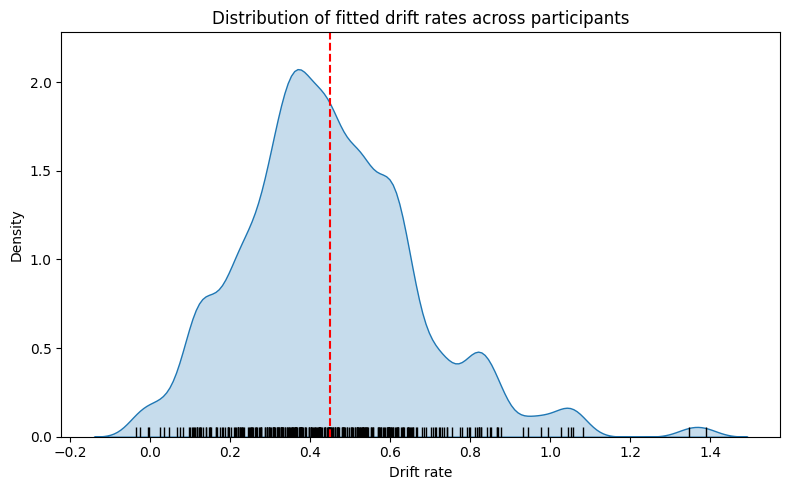

In [82]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_v_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_v_all['mean'], color='k')
plt.axvline(df_v_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Drift rate")
plt.ylabel("Density")
plt.title("Distribution of fitted drift rates across participants")
plt.tight_layout()
plt.show()

# th

In [62]:
df_th_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,1.372289,0.107542,1.188120,1.569405,0.007242,0.005181,351.655977,405.102041,1.012536,906.562682
std,0.454172,0.095103,0.360429,0.587963,0.010217,0.007392,126.319879,129.667337,0.032914,118.028002
min,0.517000,0.023000,0.477000,0.561000,0.002000,0.001000,6.000000,28.000000,1.000000,708.000000
25%,1.045500,0.066000,0.929500,1.170500,0.003000,0.002000,266.500000,341.500000,1.000000,803.500000
50%,1.281000,0.086000,1.121000,1.445000,0.005000,0.003000,368.000000,427.000000,1.010000,900.000000
75%,1.593500,0.110000,1.372000,1.808500,0.006000,0.004000,447.000000,488.500000,1.010000,1008.500000
max,3.884000,0.848000,3.243000,4.645000,0.081000,0.057000,635.000000,660.000000,1.420000,1113.000000


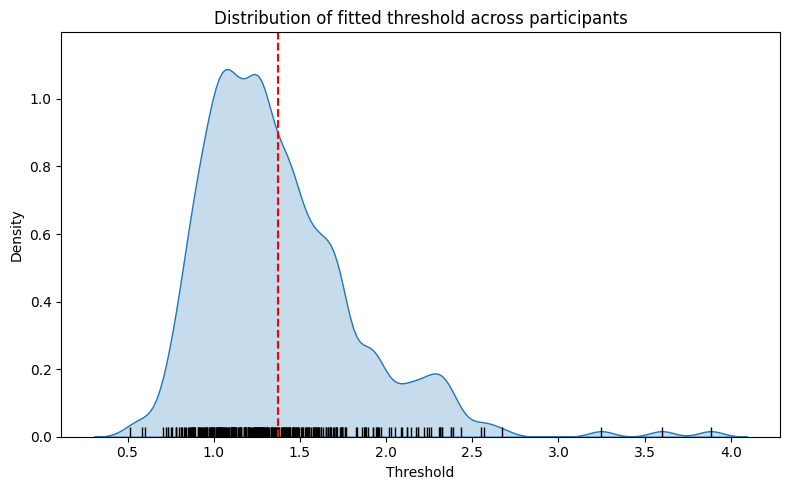

In [83]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_th_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_th_all['mean'], color='k')
plt.axvline(df_th_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Threshold")
plt.ylabel("Density")
plt.title("Distribution of fitted threshold across participants")
plt.tight_layout()
plt.show()

# ndt

In [64]:
df_t_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,0.799248,0.087227,0.639694,0.949662,0.007706,0.005595,286.819242,314.440233,1.017638,906.562682
std,0.309750,0.063768,0.305122,0.353277,0.017123,0.013334,119.727161,129.888217,0.048948,118.028002
min,0.013000,0.007000,0.000000,0.036000,0.001000,0.000000,5.000000,18.000000,1.000000,708.000000
25%,0.615000,0.042000,0.473500,0.713500,0.003000,0.002000,205.500000,226.000000,1.000000,803.500000
50%,0.730000,0.068000,0.610000,0.867000,0.004000,0.003000,299.000000,319.000000,1.010000,900.000000
75%,0.932500,0.109500,0.782500,1.092500,0.008000,0.006000,370.500000,408.000000,1.020000,1008.500000
max,2.734000,0.480000,2.179000,3.490000,0.264000,0.209000,734.000000,655.000000,1.680000,1113.000000


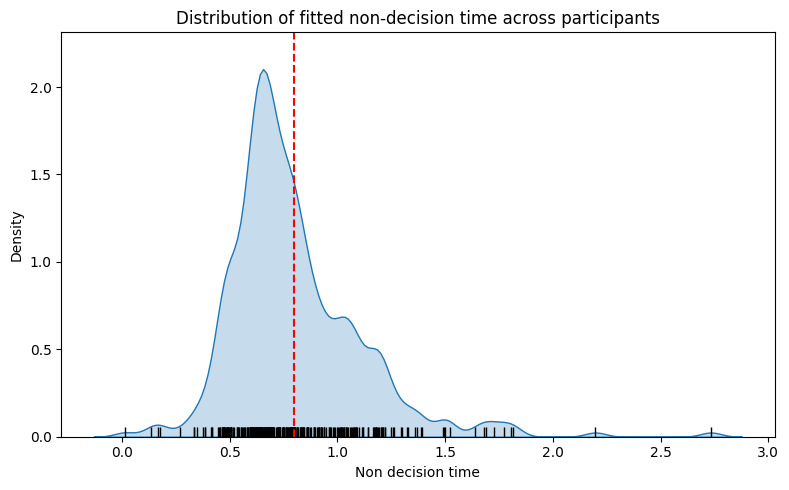

In [84]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_t_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_t_all['mean'], color='k')
plt.axvline(df_t_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Non decision time")
plt.ylabel("Density")
plt.title("Distribution of fitted non-decision time across participants")
plt.tight_layout()
plt.show()

# initial bias

In [66]:
df_z_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.00000,343.000000,343.000000
mean,0.520872,0.051452,0.425222,0.615595,0.003329,0.002443,325.644315,398.87172,1.012536,906.562682
std,0.060931,0.010895,0.062346,0.064944,0.002357,0.001678,109.797935,124.77660,0.029681,118.028002
min,0.332000,0.034000,0.241000,0.415000,0.001000,0.001000,8.000000,20.00000,1.000000,708.000000
25%,0.482000,0.045000,0.386000,0.575500,0.002000,0.002000,264.000000,319.50000,1.000000,803.500000
50%,0.519000,0.049000,0.425000,0.616000,0.003000,0.002000,335.000000,408.00000,1.010000,900.000000
75%,0.559500,0.054000,0.467000,0.652500,0.003000,0.002000,402.000000,486.50000,1.010000,1008.500000
max,0.784000,0.119000,0.717000,0.879000,0.025000,0.018000,648.000000,697.00000,1.340000,1113.000000


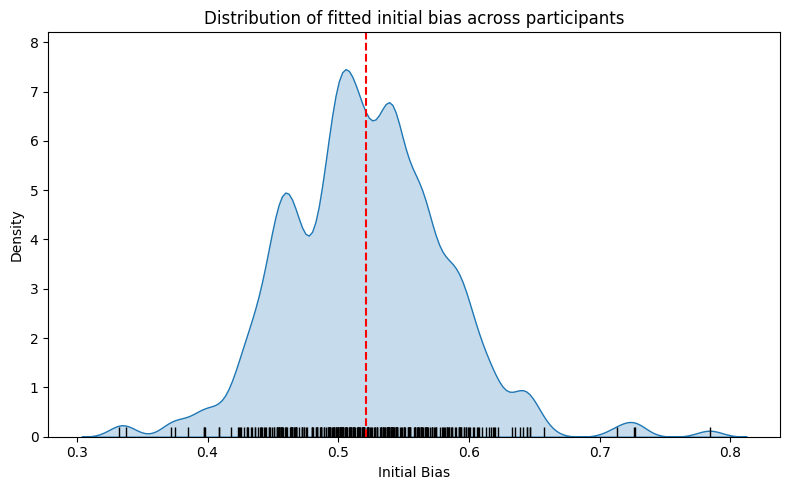

In [85]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_z_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_z_all['mean'], color='k')
plt.axvline(df_z_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Initial Bias")
plt.ylabel("Density")
plt.title("Distribution of fitted initial bias across participants")
plt.tight_layout()
plt.show()